In [1]:
%matplotlib widget
import torch
import warnings
import os
import copy
import subprocess
import shlex
import matplotlib.pyplot as plt
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)
from tqdm.autonotebook import tqdm
from torch.profiler import profile,  ProfilerActivity
if torch.cuda.is_available():
    os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'

from diffSPH.sampling import buildDomainDescription
from diffSPH.modules.adaptiveSmoothingASPH import n_h_to_nH
from diffSPH.plotting import visualizeParticles, updatePlot
from diffSPH.integration import getIntegrator
from diffSPH.util import volumeToSupport
from diffSPH.boundary import sampleDomainSDF
from diffSPH.kernels import Kernel_Scale
from diffSPH.sdf import getSDF, sdfFunctions, operatorDict, sampleSDF
from diffSPH.regions import buildRegion, filterRegion, plotRegions
from diffSPH.modules.timestep import computeTimestep
from diffSPH.schemes.initializers import initializeSimulation, updateBodyParticles
from diffSPH.schemes.deltaSPH import deltaPlusSPHScheme, DeltaPlusSPHSystem
from diffSPH.schema import getSimulationScheme
from diffSPH.enums import *
from exampleUtil import setupExampleSimulation, runSimulation, postProcess
from diffSPH.sampling import sampleDivergenceFreeNoise
import math
from diffSPH.sampling import sampleDivergenceFreeNoise
from diffSPH.modules.particleShifting import solveShifting, shuffleParticles
import numpy as np
import datetime

In [2]:
simulationName = 'Bounded Random Flow'

octaves = 4
lacunarity = 2
persistence = 0.5
baseFrequency = 2
tileable = True
kind = 'perlin'
seed = 45906734
obstacle = False
caseName = f'boundedRandomFlow_{octaves}_{lacunarity}_{persistence}_{baseFrequency}_{tileable}_{kind}_{seed}_{"with" if obstacle else "without"}'

repeat = 1

currentTime = datetime.datetime.now()
timestamp = currentTime.strftime("%Y-%m-%d_%H-%M-%S")

domainBoundary = True

# exportName = f'07_boundedRandomFlow_{octaves}_{lacunarity}_{persistence}_{baseFrequency}_{tileable}_{kind}_{seed}_{"with" if obstacle else "without"}'

L = 2
nx = 32
nx = nx * repeat
dx = L / nx
targetDt = 0.000125
rho0 = 1
freeSurface = False
band = 4 if domainBoundary else 0
fps = 50
timeLimit = 4

kernel = KernelType.Wendland4
scheme = SimulationScheme.DeltaSPH
integrationScheme = IntegrationSchemeType.symplecticEuler

device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
dtype = torch.float32
targetNeighbors = n_h_to_nH(4, 2)
c_s = 0.3 * volumeToSupport(dx**2, targetNeighbors, 2) / Kernel_Scale(kernel, 2) / targetDt
exportInterval = 1 / fps
plotInterval = int(math.ceil(exportInterval / targetDt))
timesteps = int(timeLimit / targetDt)

print(f'Running simulation {caseName} with {timesteps} timesteps, targetDt = {targetDt}, exportInterval = {exportInterval}, plotInterval = {plotInterval}, particles = {nx**2}')
print(f'Using {device} with dtype {dtype}, kernel = {kernel.name}, integration scheme = {integrationScheme.name}, targetNeighbors = {targetNeighbors:.2g}, c_s = {c_s:.1f}')

Running simulation boundedRandomFlow_4_2_0.5_2_True_perlin_45906734_without with 32000 timesteps, targetDt = 0.000125, exportInterval = 0.02, plotInterval = 160, particles = 1024
Using cuda:0 with dtype torch.float32, kernel = Wendland4, integration scheme = symplecticEuler, targetNeighbors = 50, c_s = 276.3


In [3]:

imagePrefix = f'./images/{caseName}_{nx**2}_{timestamp}/'
exportName = f'./data/{caseName}_{nx**2}_{timestamp}.h5'
os.makedirs(os.path.dirname(exportName), exist_ok = True)
os.makedirs(imagePrefix, exist_ok = True)


In [4]:
dim = 2
CFL = 0.3

domain = buildDomainDescription(l = L + dx * (band) * 2, dim = dim, periodic = True, device = device, dtype = dtype)
interiorDomain = buildDomainDescription(l = L, dim = dim, periodic = not domainBoundary, device = device, dtype = dtype)
wrappedKernel = kernel

if repeat > 1:
    domainL = domain.max - domain.min
    domainL2 = interiorDomain.max - interiorDomain.min
    domain.min = torch.zeros_like(domain.min)
    domain.max = torch.ones_like(domain.max) * domainL2 * repeat
    domain.min = domain.min - dx * band * 2
    domain.max = domain.max + dx * band * 2

    interiorDomain.min = torch.zeros_like(interiorDomain.min)
    interiorDomain.max = torch.ones_like(interiorDomain.max) * domainL2 * repeat


simulator, SimulationSystem, config, integrator = getSimulationScheme(
     scheme, kernel, integrationScheme, 
     1.0, targetNeighbors, domain)
integrationScheme = getIntegrator(integrationScheme)

config['particle'] = {
    'nx': nx + 2 * band,
    'dx': L/nx,
    'targetNeighbors': targetNeighbors,
    'band': band
}
config['fluid'] = {
    'rho0': rho0,
    'c_s': c_s
}
config['surfaceDetection']['active'] = freeSurface
config['shifting']['freeSurface'] = freeSurface

config['diffusion']['boundary'] = 0.0

In [5]:
print(domain, interiorDomain)

DomainDescription(min=tensor([-1.2500, -1.2500], device='cuda:0'), max=tensor([1.2500, 1.2500], device='cuda:0'), periodic=tensor([True, True], device='cuda:0'), dim=2) DomainDescription(min=tensor([-1., -1.], device='cuda:0'), max=tensor([1., 1.], device='cuda:0'), periodic=tensor([False, False], device='cuda:0'), dim=2)


In [6]:
fluid_sdf = lambda x: sampleDomainSDF(x, domain, invert = True)
domain_sdf = lambda x: sampleDomainSDF(x, interiorDomain, invert = False)
obstacle_sdf = lambda points: sampleSDF(points, lambda x: getSDF('circle')['function'](x, torch.tensor(1/4).to(points.device)), invert = False)

box_sdf = lambda points: sampleSDF(points, lambda x: getSDF('box')['function'](x, torch.tensor([0.5,0.5]).to(points.device)))

inlet_sdf = lambda points: sampleSDF(points, operatorDict['translate'](lambda x: getSDF('box')['function'](x, torch.tensor([0.125,0.125]).to(points.device)), torch.tensor([-0.5,0.5]).to(points.device)), invert = False)
outlet_sdf = lambda points: sampleSDF(points, operatorDict['translate'](lambda x: getSDF('box')['function'](x, torch.tensor([0.125,0.125]).to(points.device)), torch.tensor([0.5,-0.5]).to(points.device)), invert = False)
outletBuffer_sdf = lambda points: sampleSDF(points, operatorDict['translate'](lambda x: getSDF('box')['function'](x, torch.tensor([0.25,0.25]).to(points.device)), torch.tensor([0.5,-0.5]).to(points.device)), invert = False)


obstacle = True

regions = []

if domainBoundary:
    regions.append(buildRegion(sdf = domain_sdf, config = config, type = 'boundary', kind = 'constant'))
if obstacle:
    if repeat > 1:
        for rx in range(repeat):
            for ry in range(repeat):
                offset = torch.tensor([domainL2[0]/2 + rx * domainL2[0], domainL2[1]/2 + ry * domainL2[1]]).to(device)
                regions.append(buildRegion(sdf = operatorDict['translate'](obstacle_sdf, offset), config = config, type = 'boundary', kind = 'zero'))

        # obstacle_sdf = lambda points: sampleSDF(points, lambda x: getSDF('circle')['function'](x, torch.tensor(1/4).to(points.device)), invert = False)

    else:
        regions.append(buildRegion(sdf = obstacle_sdf, config = config, type = 'boundary', kind = 'zero'))
regions.append(buildRegion(sdf = fluid_sdf, config = config, type = 'fluid'))


# regions.append(buildRegion(sdf = inlet_sdf, config = config, type = 'inlet', dirichletValues={'densities': config['fluid']['rho0'], 'velocities': torch.tensor([1,0], device = device, dtype = dtype)}, updateValues = {'densities': 0, 'velocities': torch.tensor([0,0], device = device, dtype = dtype)}))

# regions.append(buildRegion(sdf = outlet_sdf, config = config, type = 'outlet'))
# regions.append(buildRegion(sdf = outletBuffer_sdf, config = config, type = 'buffer', bufferValues = ['densities', 'velocities', 'pressures']))

# regions.append(buildRegion(sdf = box_sdf, config = config, type = 'dirichlet', dirichletValues={'densities': 2.0, 'velocities': torch.tensor([1,2], device = device, dtype = dtype), 'pressures': lambda x: torch.where(x[:,0] > 0, 0.0, 1.0)}, updateValues = {'densities': 2.0}))


for region in regions:
    region = filterRegion(region, regions)

# print(regions)


In [7]:
# from diffSPH.sampling import sampleDivergenceFreeNoise, generateRamp

particleState, config, rigidBodies = initializeSimulation(scheme, config, regions)
# particleState.positions = shuffleParticles(particleState, config, 4)

if repeat > 1:
    noiseDomain = buildDomainDescription(l = L + dx * (band) * 2, dim = dim, periodic = True, device = device, dtype = dtype)
else:
    noiseDomain = domain


In [8]:
print(nx)
if nx == 32:
    s = 48
if nx == 64:
    s = 12
if nx == 128:
    s = 2
if nx == 256:
    s = 0.25
    # print(s)

32


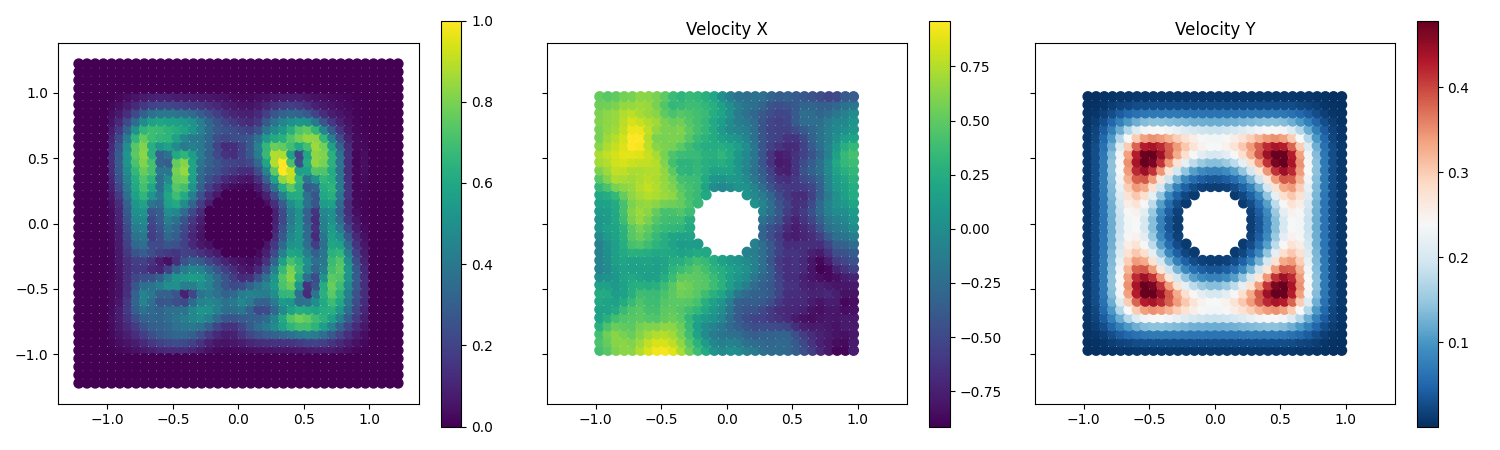

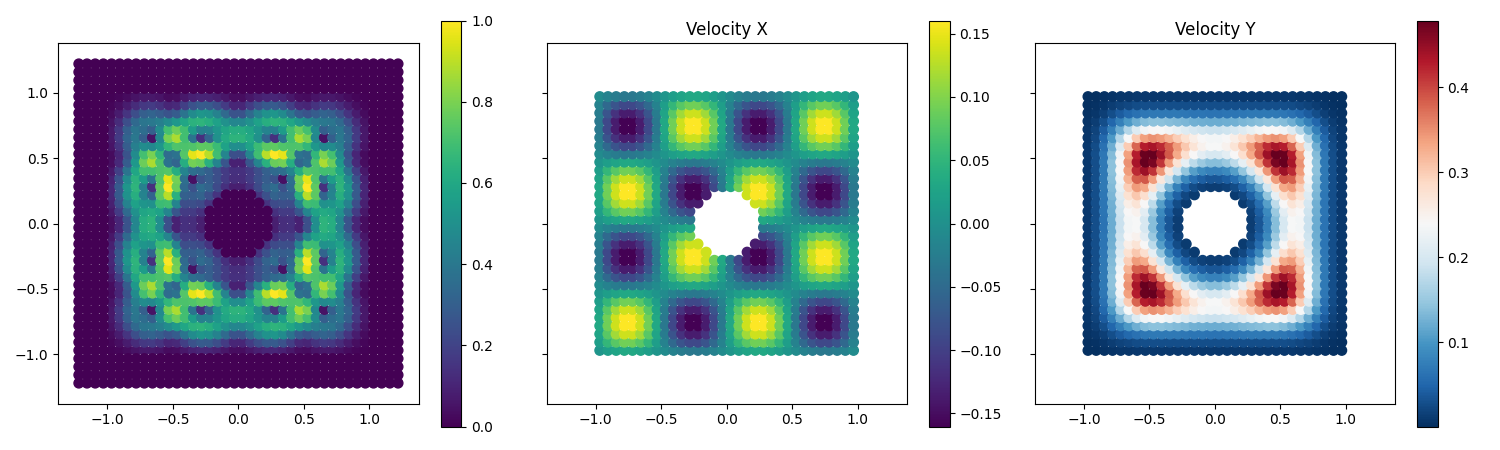

In [9]:
from samplingUtils import plotSampling, sampleDivergenceFreeNoise, sampleTGV

velocities, potential, ramp = sampleDivergenceFreeNoise(particleState, noiseDomain, config, nx * 2, smoothingSteps = 4, octaves = octaves, lacunarity = lacunarity, persistence = persistence, baseFrequency = baseFrequency, tileable = tileable, kind = kind, seed = seed)

fig, axis = plotSampling(particleState, domain, config, velocities, ramp, potential, s = s)

velocities, potential, ramp = sampleTGV(particleState, noiseDomain, config, k_ = 4, smoothingSteps = 4)
fig, axis = plotSampling(particleState, domain, config, velocities, ramp, potential, s = s)

In [64]:
nx = [32, 64, 128, 256, 512]
c_s = 10

    
if c_s == 20:
    dts = [2e-3, 1e-3, 5e-4, 2.5e-4, 1.25e-4]
elif c_s == 10:
    dts = [4e-3, 2e-3, 1e-3, 5e-4, 2.5e-4]
elif c_s == 30:
    dts = [1e-3, 5e-4, 2.5e-4, 1.25e-4, 6.25e-5]

normalizeEnergy = False
cases = 1
seeds = np.random.randint(0, 2**32 - 1, size = cases)

# for [n, dt] in zip(nx[-2:], dts[-2:]):
for [n, dt] in zip(nx, dts):
    for i in range(cases):
        # print(f'python wcflows.py {"--normalizeEnergy" if normalizeEnergy else ""} --cs {c_s} --nx {n} --dt {dt} --velocityNoise --seed {seeds[i]} --no-plot --export --exportDir /mnt/ssdraid/rene/datasets/weaklyCompressible/noSlip/')
        # print(f'python wcflows.py {"--normalizeEnergy" if normalizeEnergy else ""} --cs {c_s} --obstacle --nx {n} --dt {dt} --velocityNoise --seed {seeds[i]} --no-plot --export --exportDir /mnt/ssdraid/rene/datasets/weaklyCompressible/noSlip/')
        # print(f'python wcflows.py {"--normalizeEnergy" if normalizeEnergy else ""} --cs {c_s} --domainBoundary --nx {n} --dt {dt} --velocityNoise --seed {seeds[i]} --no-plot --export --exportDir /mnt/ssdraid/rene/datasets/weaklyCompressible/noSlip/')
        # print(f'python wcflows.py {"--normalizeEnergy" if normalizeEnergy else ""} --cs {c_s} --domainBoundary --obstacle --nx {n} --dt {dt} --velocityNoise --seed {seeds[i]} --no-plot --export --exportDir /mnt/ssdraid/rene/datasets/weaklyCompressible/noSlip/')
        print(f'python wcflows.py {"--normalizeEnergy" if normalizeEnergy else ""} --cs {c_s} --nx {n} --dt {dt} --velocityNoise --seed {seeds[i]} --boundaryViscosity 0.00 --no-plot --export --exportDir /mnt/ssdraid/rene/datasets/weaklyCompressible/freeSlip/')
        print(f'python wcflows.py {"--normalizeEnergy" if normalizeEnergy else ""} --cs {c_s} --obstacle --nx {n} --dt {dt} --velocityNoise --seed {seeds[i]} --boundaryViscosity 0.00 --no-plot --export --exportDir /mnt/ssdraid/rene/datasets/weaklyCompressible/freeSlip/')
        print(f'python wcflows.py {"--normalizeEnergy" if normalizeEnergy else ""} --cs {c_s} --domainBoundary --nx {n} --dt {dt} --velocityNoise --seed {seeds[i]} --boundaryViscosity 0.00 --no-plot --export --exportDir /mnt/ssdraid/rene/datasets/weaklyCompressible/freeSlip/')
        print(f'python wcflows.py {"--normalizeEnergy" if normalizeEnergy else ""} --cs {c_s} --domainBoundary --obstacle --nx {n} --dt {dt} --velocityNoise --seed {seeds[i]} --boundaryViscosity 0.00 --no-plot --export --exportDir /mnt/ssdraid/rene/datasets/weaklyCompressible/freeSlip/')



python wcflows.py  --cs 10 --nx 32 --dt 0.004 --velocityNoise --seed 3989629583 --boundaryViscosity 0.00 --no-plot --export --exportDir /mnt/ssdraid/rene/datasets/weaklyCompressible/freeSlip/
python wcflows.py  --cs 10 --obstacle --nx 32 --dt 0.004 --velocityNoise --seed 3989629583 --boundaryViscosity 0.00 --no-plot --export --exportDir /mnt/ssdraid/rene/datasets/weaklyCompressible/freeSlip/
python wcflows.py  --cs 10 --domainBoundary --nx 32 --dt 0.004 --velocityNoise --seed 3989629583 --boundaryViscosity 0.00 --no-plot --export --exportDir /mnt/ssdraid/rene/datasets/weaklyCompressible/freeSlip/
python wcflows.py  --cs 10 --domainBoundary --obstacle --nx 32 --dt 0.004 --velocityNoise --seed 3989629583 --boundaryViscosity 0.00 --no-plot --export --exportDir /mnt/ssdraid/rene/datasets/weaklyCompressible/freeSlip/
python wcflows.py  --cs 10 --nx 64 --dt 0.002 --velocityNoise --seed 3989629583 --boundaryViscosity 0.00 --no-plot --export --exportDir /mnt/ssdraid/rene/datasets/weaklyCompres

In [102]:
4*4*8

128

In [103]:
print(f'Minimum velocities: {particleState.velocities.min(dim = 0).values}')
print(f'Maximum velocities: {particleState.velocities.max(dim = 0).values}')
print(f'Mean velocities: {particleState.velocities.mean(dim = 0)}')

print(f'Velocity Magnitudes: min: {particleState.velocities.norm(dim = -1).min().item()}, max: {particleState.velocities.norm(dim = -1).max().item()}, mean: {particleState.velocities.norm(dim = -1).mean().item()}')

E_k0 = 0.5 * particleState.masses * torch.linalg.norm(particleState.velocities, dim = -1)**2
print(f'Minimum kinetic energy: {E_k0.min().item()}')
print(f'Maximum kinetic energy: {E_k0.max().item()}')
print(f'Mean kinetic energy: {E_k0.mean().item()}')

totalInitialEnergy = E_k0.sum()
print(f'Total initial energy: {totalInitialEnergy.item()}')

# particleState.velocities /= E_k0.sum().sqrt()

# print(f'Velocity Magnitudes: min: {particleState.velocities.norm(dim = -1).min().item()}, max: {particleState.velocities.norm(dim = -1).max().item()}, mean: {particleState.velocities.norm(dim = -1).mean().item()}')
# E_k0 = 0.5 * particleState.masses * torch.linalg.norm(particleState.velocities, dim = -1)**2
# print(f'Minimum kinetic energy: {E_k0.min().item()}')
# print(f'Maximum kinetic energy: {E_k0.max().item()}')
# print(f'Mean kinetic energy: {E_k0.mean().item()}')

# totalInitialEnergy = E_k0.sum()
# print(f'Total initial energy: {totalInitialEnergy.item()}')


Minimum velocities: tensor([-0.8047, -0.8794], device='cuda:0')
Maximum velocities: tensor([0.8190, 0.9959], device='cuda:0')
Mean velocities: tensor([-3.3562e-04,  6.0768e-05], device='cuda:0')
Velocity Magnitudes: min: 0.0, max: 0.9999999403953552, mean: 0.16267362236976624
Minimum kinetic energy: 0.0
Maximum kinetic energy: 0.00012207029794808477
Mean kinetic energy: 6.84553515384323e-06
Total initial energy: 0.1466313600540161


In [104]:
from diffSPH.neighborhood import evaluateNeighborhood, filterNeighborhoodByKind, coo_to_csr

dt = computeTimestep(scheme, 1e-2, particleState, config, None)
particles = copy.deepcopy(particleState)
particleSystem = DeltaPlusSPHSystem(config['domain'], None, 0., copy.deepcopy(particleState), 'momentum', None, rigidBodies = config['rigidBodies'], regions = config['regions'], config = config)

for rigidBody in config['rigidBodies']:
    particleState = updateBodyParticles(scheme, particleState, rigidBody)

## Setup values for plotting 

kineticEnergy = 0.5 * particleState.densities * (particleState.velocities ** 2).sum(1)

t = 0
E_k0 = 0.5 * particleState.masses * torch.linalg.norm(particleState.velocities, dim = -1)**2
E_k = 0.5 * particleState.masses * torch.linalg.norm(particleState.velocities, dim = -1)**2

rhoMin = particleState.densities.min().detach().cpu().item() / config['fluid']['rho0']
rhoMean = particleState.densities.mean().detach().cpu().item() / config['fluid']['rho0']
rhoMax = particleState.densities.max().detach().cpu().item() / config['fluid']['rho0']

initialVelocity = particleState.velocities.clone()
initialDensities = particleState.densities.clone()
initialPotentialEnergy = None

if config['gravity']['active']:
    if 'mode' in config['gravity'] and config['gravity']['mode'] == 'potential':
        B = config['gravity']['magnitude']
        initialPotentialEnergy = 0.5 * B**2 * particleState.masses / config['fluid']['rho0'] * particleState.densities * torch.linalg.norm(particleState.positions, dim = -1)**2

initialKineticEnergy = 0.5 * particleState.masses / config['fluid']['rho0'] * particleState.densities * torch.linalg.norm(initialVelocity, dim = -1)**2
initialEnergy = initialKineticEnergy + initialPotentialEnergy if initialPotentialEnergy is not None else initialKineticEnergy
totalInitialEnergy = (initialEnergy).sum().detach().cpu().item()
totalEnergy = (initialEnergy).sum().detach().cpu().item()

actualState = particleSystem

neighborhood, neighbors = evaluateNeighborhood(particles, domain, kernel, verletScale = 1.0, mode = SupportScheme.SuperSymmetric, priorNeighborhood=None)
particles.numNeighbors = coo_to_csr(filterNeighborhoodByKind(particles, neighbors.neighbors, which = 'noghost')).rowEntries
actualState.systemState.numNeighbors = particles.numNeighbors

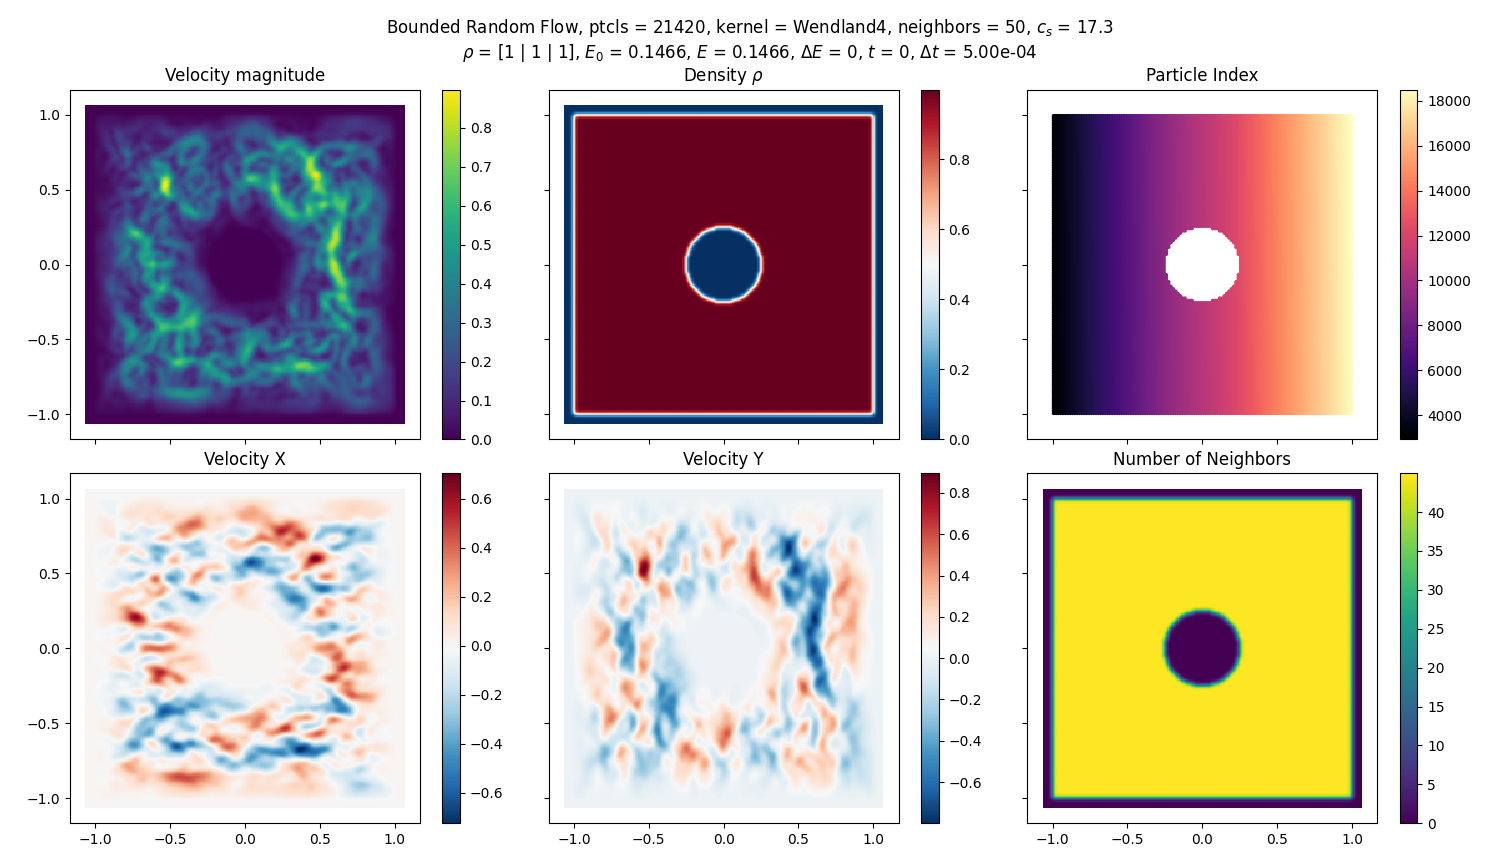

In [105]:

def plotScalar(fig, axis, label, fluidParticles, quantity, domain, solverConfig, s, gridVisualization=True, gridResolution=256, mapping = None, cmap = 'viridis', vmin=None, vmax=None, operator = None):
    return visualizeParticles(fig, axis,
                     particles = fluidParticles, 
                     domain = domain, 
                     quantity = quantity, 
                     which = 'fluid',
                     visualizeBoth=False,
                     kernel = solverConfig['kernel'],
                     plotDomain = False,
                     operation= operator,
                    #  scaling = 'sym',
                     cmap = cmap,
                     midPoint=1.5,
                     mapping = mapping,
                     title=label,
                     markerSize = s,
                     gridVisualization=gridVisualization, gridResolution=gridResolution, vmin=vmin, vmax=vmax)


fig, axis = plt.subplots(2, 3, figsize=(15, 8.5), squeeze=False, sharex=True, sharey=True)

s = 4
fluidParticles = actualState.systemState


densityPlotState        = plotScalar(fig, axis[0,0], 'Velocity magnitude',     fluidParticles, fluidParticles.velocities,           domain, config, s, gridVisualization=True, gridResolution=256, cmap = 'viridis', mapping = 'L2')
internalEnergyPlotState = plotScalar(fig, axis[0,1], 'Density $\\rho$', fluidParticles, fluidParticles.densities ,     domain, config, s, gridVisualization=True, gridResolution=256, cmap = 'RdBu_r', mapping = None)
supportPlotState        = plotScalar(fig, axis[0,2], 'Particle Index',         fluidParticles, fluidParticles.UIDs,            domain, config, s, gridVisualization=False, gridResolution=256, cmap = 'magma', mapping = None)
numNeighborsPlotState   = plotScalar(fig, axis[1,2], 'Number of Neighbors', fluidParticles, fluidParticles.numNeighbors,        domain, config, s, gridVisualization=True, gridResolution=256, mapping = '.y', cmap = 'viridis')
velocityXPlotState      = plotScalar(fig, axis[1,0], 'Velocity X',          fluidParticles, fluidParticles.velocities,          domain, config, s, gridVisualization=True, gridResolution=256, mapping = '.x', cmap = 'RdBu_r')
velocityYPlotState      = plotScalar(fig, axis[1,1], 'Velocity Y',          fluidParticles, fluidParticles.velocities,          domain, config, s, gridVisualization=True, gridResolution=256, mapping = '.y', cmap = 'RdBu_r')

# for ax in axis.flatten():
    # ax.set_xlim(-1, 1)
    # ax.set_ylim(-1,1)
# kineticEnergy = 0.5 * (torch.linalg.norm(actualState.systemState.velocities, dim = -1) **2 * actualState.systemState.masses).sum()
# thermalEnergy = (actualState.systemState.internalEnergies * actualState.systemState.masses).sum()
# totalEnergy = kineticEnergy + thermalEnergy


fig.suptitle(f'{simulationName}, ptcls = {particleState.positions.shape[0]}, kernel = {config["kernel"].name}, neighbors = {config["targetNeighbors"]:.2g}, $c_s$ = {config["fluid"]["c_s"]:.1f}\n$\\rho$ = [{rhoMin:.4g} | {rhoMean:.4g} | {rhoMax:.4g}], $E_0$ = {totalInitialEnergy:.4g}, $E$ = {totalEnergy:.4g}, $\\Delta E$ = {totalEnergy - totalInitialEnergy:.4g}, $t$ = {particleSystem.t:.4g}, $\Delta t$ = {dt:.2e}')


fig.tight_layout()

fig.savefig(f'{imagePrefix}frame_{0:05d}.png', dpi = 200)

In [106]:
from diffSPH.io import initializeOutputFile, writeParticleData, writeParticleDataMinimal

outFile = initializeOutputFile(exportName, actualState, config,simulationName='testData')
outGroup = outFile['simulationData']
writeParticleData(outGroup, actualState, step = 0, dt = dt)

<HDF5 group "/simulationData/000000" (15 members)>

In [107]:

states = []
# dt = newDt
# actualState.systemState.divergence = torch.zeros_like(actualState.systemState.densities)
for i in (tq:=tqdm(range(timesteps))):
# while(True):
    actualState, currentState, updates = integrator.function(actualState, dt, simulator, config, priorStep = actualState.priorStep)
    actualState.priorStep = [updates[-1], currentState[-1]]
    # if i%100 == 0:
        # states.append(copy.deepcopy(simulationState).to(dtype = torch.float32, device = 'cpu'))

    kineticEnergy = 0.5 * (torch.linalg.norm(actualState.systemState.velocities, dim = -1) **2 * actualState.systemState.masses).sum()
    thermalEnergy = 0# (actualState.systemState.internalEnergies * actualState.systemState.masses).sum()
    totalEnergy = kineticEnergy + thermalEnergy

    rhoMin = actualState.systemState.densities.min().detach().cpu().item() / config['fluid']['rho0']
    rhoMean = actualState.systemState.densities.mean().detach().cpu().item() / config['fluid']['rho0']
    rhoMax = actualState.systemState.densities.max().detach().cpu().item() / config['fluid']['rho0']

    rhoMaxFromMean = rhoMax - rhoMean
    rhoMinFromMean = rhoMean - rhoMin
    rhoMaxVis = max(rhoMaxFromMean, abs(rhoMinFromMean))
    rhovmin = rhoMean - rhoMaxVis
    rhovmax = rhoMean + rhoMaxVis


    tq.set_postfix({
        'Kinetic Energy': kineticEnergy.item(),
        'Total Energy': totalEnergy.item(),
        'Time': actualState.t.item() if torch.is_tensor(actualState.t) else actualState.t,
    })
    t = actualState.t.item() if torch.is_tensor(actualState.t) else actualState.t

    frameGroup = writeParticleDataMinimal(outGroup, actualState, step = i+1, dt = dt)

    # frameGroup.attrs['timestepCFL'] = timestepCFL
    # frameGroup.attrs['CFLNumber'] = CFLNumber.item() if torch.is_tensor(CFLNumber) else CFLNumber
    # frameGroup.attrs['c_s_max'] = c_s_max.item() if torch.is_tensor(c_s_max) else c_s_max
    # frameGroup.attrs['h_min'] = h_min.item() if torch.is_tensor(h_min) else h_min
    # frameGroup.attrs['xi'] = xi.item() if torch.is_tensor(xi) else xi
    # frameGroup.attrs['dt_cfl'] = dt_cfl.item() if torch.is_tensor(dt_cfl) else dt_cfl
    frameGroup.attrs['kineticEnergy'] = kineticEnergy.item() if torch.is_tensor(kineticEnergy) else kineticEnergy
    frameGroup.attrs['thermalEnergy'] = thermalEnergy.item() if torch.is_tensor(thermalEnergy) else thermalEnergy
    frameGroup.attrs['totalEnergy'] = totalEnergy.item() if torch.is_tensor(totalEnergy) else totalEnergy

    if (i % plotInterval == 0 and i > 0) or i == timesteps - 1:
        updatePlot(densityPlotState, actualState.systemState, actualState.systemState.velocities)
        updatePlot(internalEnergyPlotState, actualState.systemState, actualState.systemState.densities)
        updatePlot(supportPlotState, actualState.systemState, actualState.systemState.UIDs)


        neighborhood, neighbors = evaluateNeighborhood(actualState.systemState, config['domain'], config['kernel'], verletScale = config['neighborhood']['verletScale'], mode = SupportScheme.SuperSymmetric, priorNeighborhood=actualState.neighborhoodInfo)

        numNeighbors = coo_to_csr(filterNeighborhoodByKind(actualState.systemState, neighbors.neighbors, which = 'noghost')).rowEntries
        updatePlot(numNeighborsPlotState, actualState.systemState, numNeighbors)

        # numNeighbors = coo_to_csr(filterNeighborhoodByKind(actualState.systemState, currentState[-1][1].fullAdjacency, which = 'noghost')).rowEntries
        # numNeighbors = coo_to_csr(currentState[-1][1].fullAdjacency).rowEntries

        updatePlot(velocityXPlotState, actualState.systemState, actualState.systemState.velocities)
        # for patch in axis[0,2].patches[:]:
        #     print(patch)
        #     if isinstance(patch, mpl.patches.FancyArrowPatch):
        #         patch.remove()
        updatePlot(velocityYPlotState, actualState.systemState, actualState.systemState.velocities)

        # for ax in axis.flatten():
            # ax.set_xlim(-1, 1)
            # ax.set_ylim(-1,1)

        fig.suptitle(f'{simulationName}, ptcls = {particleSystem.systemState.positions.shape[0]}, kernel = {config["kernel"].name}, neighbors = {config["targetNeighbors"]:.2g}, $c_s$ = {config["fluid"]["c_s"]:.1f}\n$\\rho$ = [{rhoMin:.4g} | {rhoMean:.4g} | {rhoMax:.4g}], $E_0$ = {totalInitialEnergy:.4g}, $E$ = {totalEnergy:.4g}, $\\Delta E$ = {totalEnergy - totalInitialEnergy:.4g}, $t$ = {t:.4g}, $\Delta t$ = {dt:.2e}')


        fig.canvas.draw()
        fig.canvas.flush_events()
        fig.savefig(f'{imagePrefix}frame_{i:05d}.png', dpi = 100)

  0%|          | 0/8000 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [28]:
outFile.close()

In [30]:

import os
import subprocess
import shlex
import imageio.v2 as imageio
from skimage.transform import resize, rescale
from skimage.io import imread


def postProcess(imagePrefix, fps, exportName, targetLongEdge = 600):
    fileList = os.listdir(imagePrefix)
    fileList = [f for f in fileList if f.endswith('.png') and f.startswith('frame_')]
    fileList = sorted(fileList)

    writer = imageio.get_writer(f'{imagePrefix}/output.mp4', fps=fps, bitrate='30M')
    for image in fileList:
        writer.append_data(imageio.imread(imagePrefix + image))
    writer.close()

    images = []
    for image in fileList:
        images.append(imread(imagePrefix + image))

    currentImageSize = images[0].shape
    currentLongEdge = max(images[0].shape[0], images[0].shape[1])
    ratio = targetLongEdge / currentLongEdge

    images = [(rescale(image, ratio, anti_aliasing=True, channel_axis=-1)*255).astype('uint8') for image in images]

    # for image in images:
        # print(image.shape)
        # break

    # images = [resizeImageLongEdge(i, 600) for i in images]

    imageio.mimsave(f'{imagePrefix}/output.gif', images, fps=fps, loop = 0)
    
    print('Copying video to videos folder')
    os.makedirs(f'./videos/', exist_ok= True)
    # subprocess.run(shlex.split(f'cp {imagePrefix}/output.mp4 ./videos/{exportName}.mp4'))
    subprocess.run(shlex.split(f'cp {imagePrefix}/output.gif ./videos/{exportName}.gif'))
    lastFrameFile = imagePrefix + fileList[-1]
    subprocess.run(shlex.split(f'cp {lastFrameFile} ./videos/{exportName}.png'))
    print('Done!')


postProcess(
    imagePrefix = imagePrefix,
    fps = 50,
    exportName = 'randomFlow',
    targetLongEdge = 1200
)
# def postProcess(imagePrefix, fps, exportName, targetLongEdge = 600):

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1500, 850) to (1504, 864) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Copying video to videos folder
Done!
